# Employee Attrition Prediction using Decision Tree Classifier

**Algorithm:** Decision Tree Classifier

---


## 1. Introduction

### Problem Statement
Predict whether an employee will leave the company (attrition) based on HR-related features using the Decision Tree algorithm.

### Dataset Information
**Source:** IBM HR Analytics Employee Attrition & Performance Dataset  
**Size:** 1,470 employee records  
**Features:** 31 independent variables (after dropping non-predictive columns)  
**Target:** Attrition (Yes / No)

### Dataset Attributes (key features)
- **Age**: Employee age
- **BusinessTravel**: Travel frequency (Non-Travel / Travel_Rarely / Travel_Frequently)
- **Department**: Department of employee
- **DistanceFromHome**: Distance from home (km)
- **Education**: Education level (1–5)
- **EnvironmentSatisfaction**: Satisfaction with work environment (1–4)
- **JobInvolvement**: Level of job involvement (1–4)
- **JobLevel**: Job level in organization
- **JobSatisfaction**: Job satisfaction rating (1–4)
- **MaritalStatus**: Single / Married / Divorced
- **MonthlyIncome**: Monthly income
- **NumCompaniesWorked**: Number of previous companies
- **OverTime**: Yes / No
- **TotalWorkingYears**: Total years of work experience
- **WorkLifeBalance**: Work-life balance rating (1–4)
- **YearsAtCompany**: Years spent at the company
- **Attrition**: Yes (left) / No (stayed) — **TARGET**


## 2. Import Libraries

In [1]:
# Install (if needed)
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
from imblearn.over_sampling import SMOTE

# For model comparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

sns.set_style('whitegrid')
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 3. Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

# Replace filename if different
df_raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 4. Exploratory Data Analysis

In [3]:
# Dataset overview
print("First 5 rows:")
display(df_raw.head())

print("\nDataset Info:")
df_raw.info()

print("\nStatistical Summary:")
display(df_raw.describe())


First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
# Missing values analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing'] > 0])
print("\nNo missing values — IBM HR dataset is clean.")


Missing Values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []

No missing values — IBM HR dataset is clean.


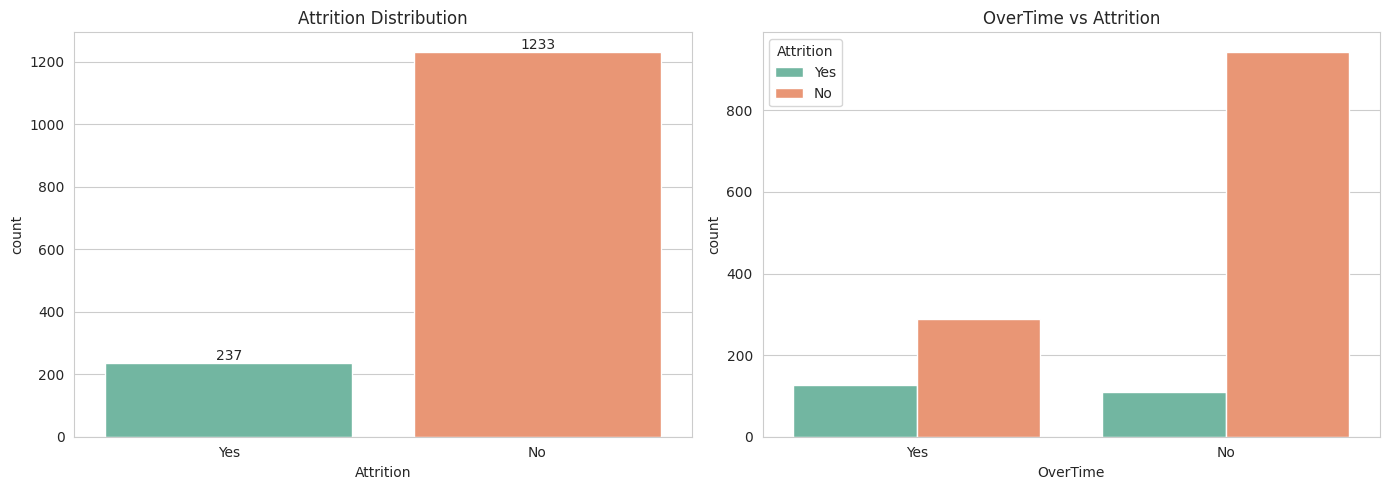


Target Distribution:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition count
ax1 = sns.countplot(x='Attrition', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Attrition Distribution')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom')

# OverTime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df_raw, palette='Set2', ax=axes[1])
axes[1].set_title('OverTime vs Attrition')
axes[1].legend(title='Attrition')

plt.tight_layout()
plt.show()

print("\nTarget Distribution:")
print(df_raw['Attrition'].value_counts(normalize=True) * 100)


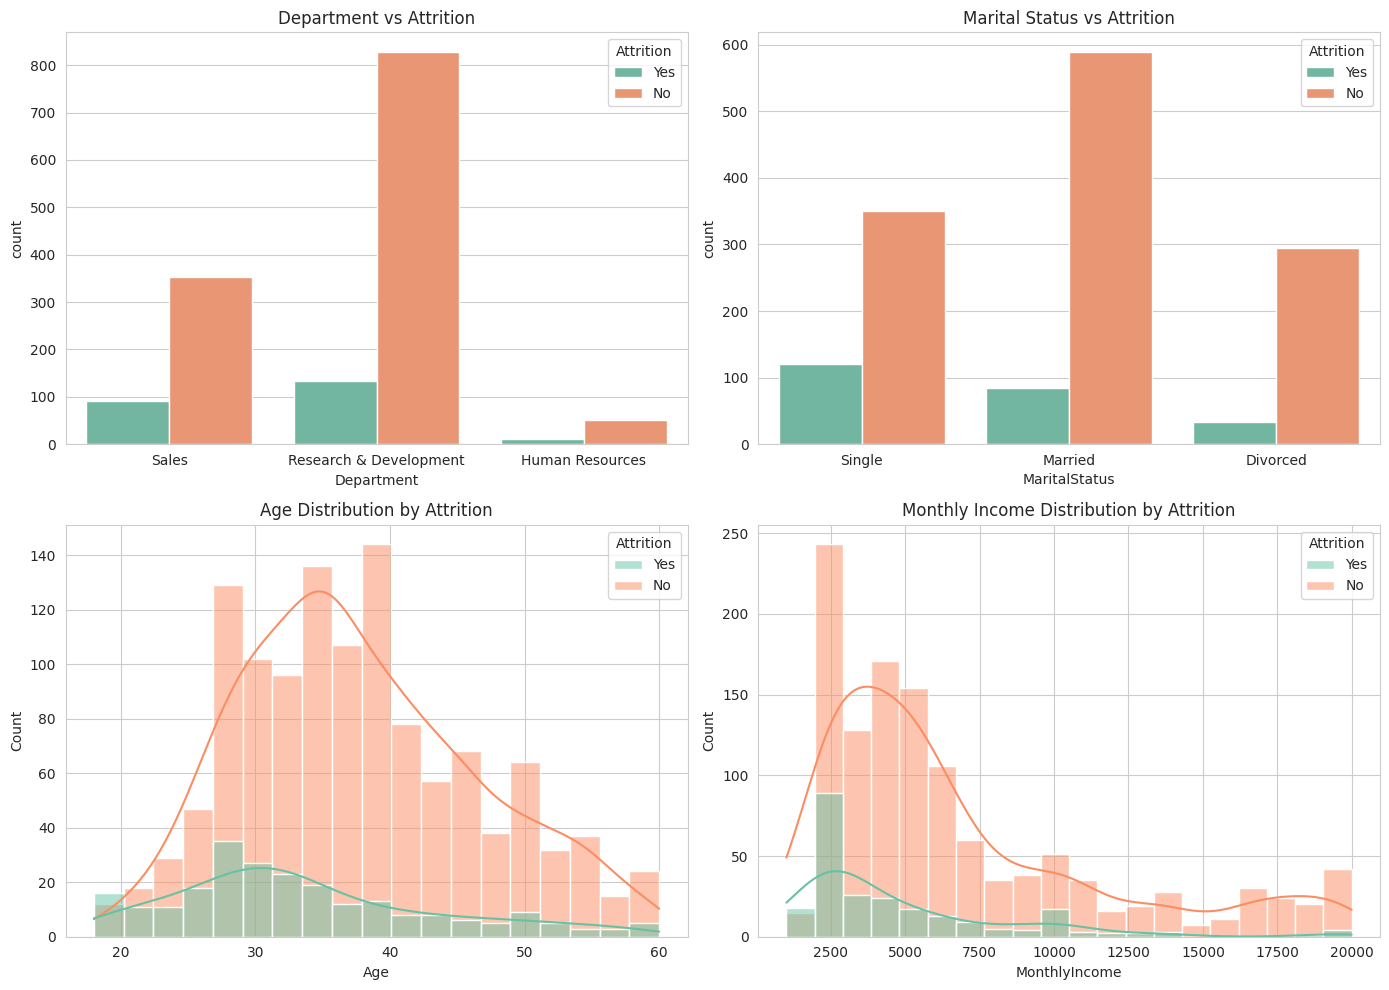

In [6]:
# Key feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Categorical features
sns.countplot(x='Department', hue='Attrition', data=df_raw, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Department vs Attrition')

sns.countplot(x='MaritalStatus', hue='Attrition', data=df_raw, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Marital Status vs Attrition')

# Numerical features
sns.histplot(data=df_raw, x='Age', hue='Attrition', kde=True, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Attrition')

sns.histplot(data=df_raw, x='MonthlyIncome', hue='Attrition', kde=True, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Income Distribution by Attrition')

plt.tight_layout()
plt.show()


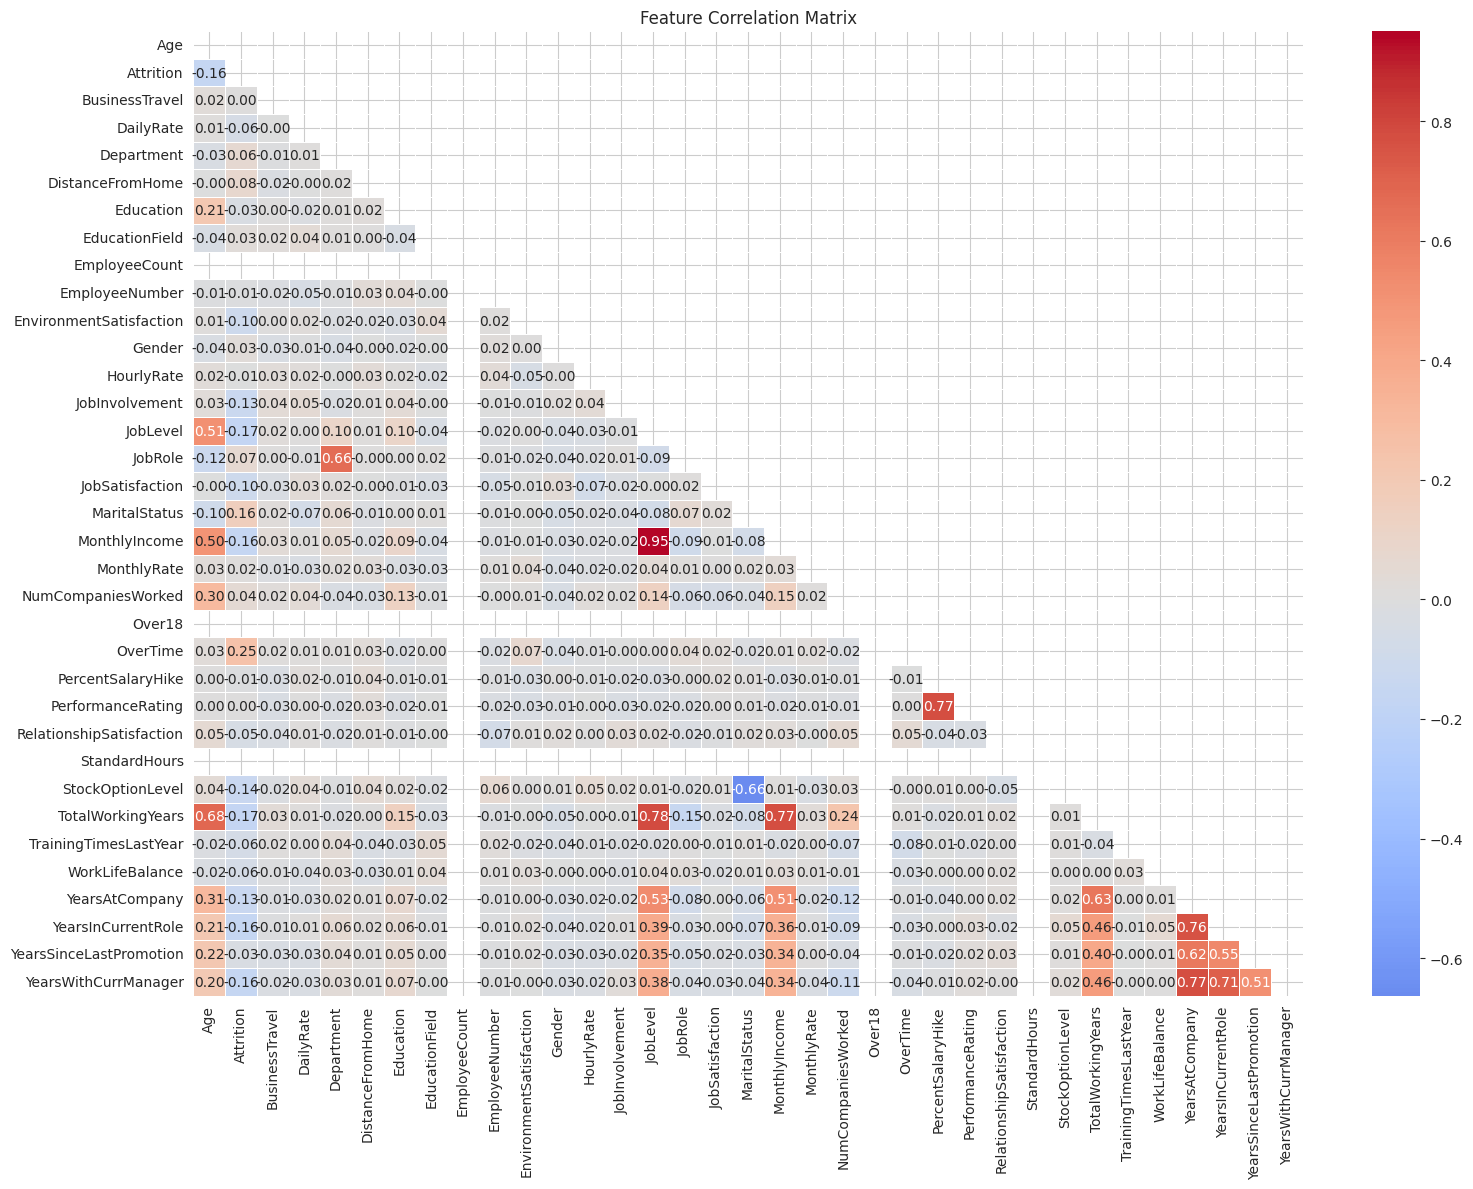

In [7]:
# Correlation heatmap (numeric columns only)
df_encoded_eda = df_raw.copy()
le_eda = LabelEncoder()
for col in df_encoded_eda.select_dtypes(include='object').columns:
    df_encoded_eda[col] = le_eda.fit_transform(df_encoded_eda[col].astype(str))

plt.figure(figsize=(16, 12))
correlation = df_encoded_eda.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))  # show lower triangle only
sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 5. Data Preprocessing

In [8]:
# These columns don't contribute to prediction
df = df_raw.copy()
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)
print(f"Columns after dropping non-predictive features: {df.shape[1]}")


Columns after dropping non-predictive features: 31


In [9]:
# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoding: Yes → 1, No → 0")


Attrition encoding: Yes → 1, No → 0


In [10]:
# Label-encode all remaining categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical encoding complete")
print(df.dtypes)


✅ Categorical encoding complete
Age                         int64
Attrition                   int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRo

In [11]:
# Feature engineering
df['IncomePerYearAtCompany'] = df['MonthlyIncome'] / (df['YearsAtCompany'] + 1)
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

print("✅ Feature engineering complete")


✅ Feature engineering complete


In [12]:
# Prepare features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Stratified train / val / test split  (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size:      {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size:       {X_test.shape}")


Train size:      (1029, 32)
Validation size: (220, 32)
Test size:       (221, 32)


In [13]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print("✅ Feature scaling applied")


✅ Feature scaling applied


In [14]:
# Handle class imbalance with SMOTE (applied ONLY on training data)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE class distribution:", np.bincount(y_train))


After SMOTE class distribution: [863 863]


## 6. Decision Tree Algorithm

### Algorithm Background

**Decision Tree** is a supervised learning algorithm that builds a tree-like model of decisions.

**How it works:**
1. Selects the best feature to split data using **Gini Impurity** or **Entropy**
2. Divides the dataset into subsets based on feature values
3. Repeats recursively until a stopping criterion is met
4. Produces interpretable if-then-else rules for classification

**Advantages:**
- Easy to interpret and visualize
- Handles both numerical and categorical data
- No feature scaling strictly required
- Provides feature importance scores

**Disadvantages:**
- Prone to overfitting without depth constraints
- Unstable — small data changes can alter the tree significantly


In [15]:
# Initialize and train the Decision Tree classifier
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)
print("✅ Decision Tree model trained successfully")


✅ Decision Tree model trained successfully


## 7. Results and Evaluation

In [17]:
# Predictions on validation set
y_val_pred       = dt_model.predict(X_val)
y_val_pred_proba = dt_model.predict_proba(X_val)[:, 1]

# Predictions on test set
y_test_pred       = dt_model.predict(X_test)
y_test_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)
roc_auc   = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 60)
print("  DECISION TREE — PERFORMANCE METRICS (Test Set)")
print("=" * 60)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print("=" * 60)


  DECISION TREE — PERFORMANCE METRICS (Test Set)
  Accuracy:  0.7738  (77.38%)
  Precision: 0.3478
  Recall:    0.4444
  F1-Score:  0.3902
  ROC-AUC:   0.6899


In [18]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                            target_names=['Stayed', 'Left']))



Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.89      0.84      0.86       185
        Left       0.35      0.44      0.39        36

    accuracy                           0.77       221
   macro avg       0.62      0.64      0.63       221
weighted avg       0.80      0.77      0.78       221



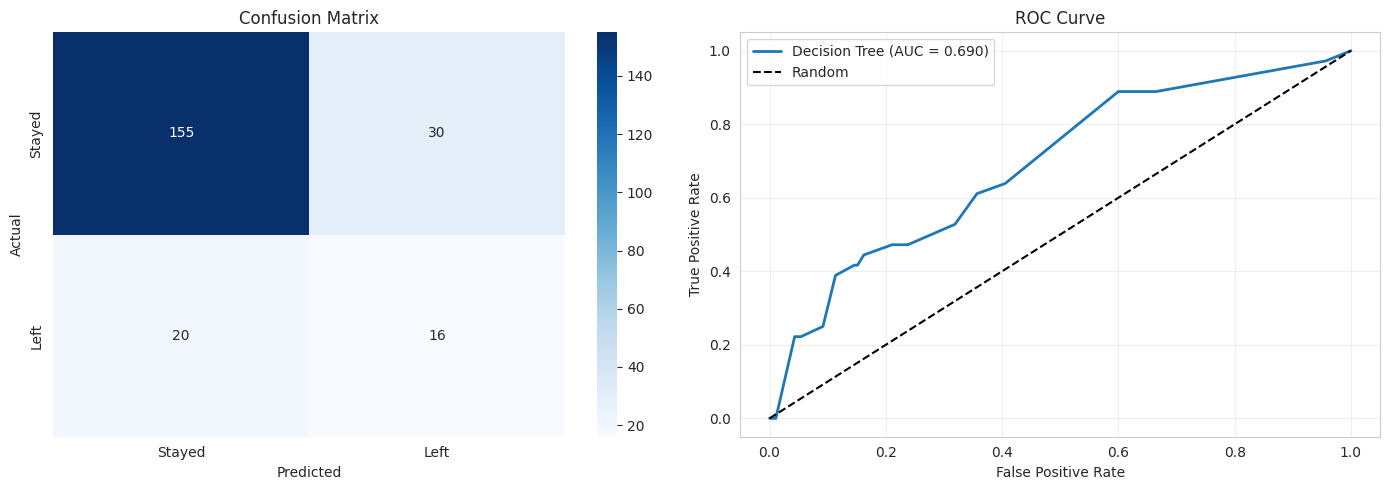

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ── ROC Curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2,
             label=f'Decision Tree (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


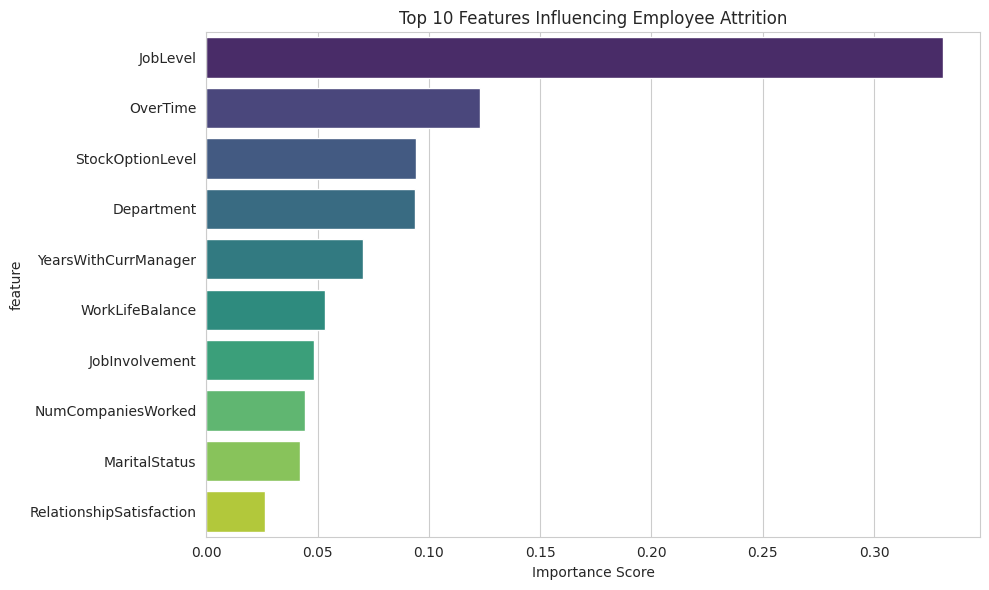


Top 5 Most Important Features:
                 feature  importance
11              JobLevel    0.331099
18              OverTime    0.123102
22      StockOptionLevel    0.094087
3             Department    0.093754
29  YearsWithCurrManager    0.070245


In [20]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': df.drop('Attrition', axis=1).columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10),
            x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features Influencing Employee Attrition')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())


## 8. Hyperparameter Tuning

In [21]:
param_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
dt_tuned = grid_search.best_estimator_
y_pred_tuned   = dt_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nTuned Model Test Accuracy: {accuracy_tuned:.4f}")
print(f"Improvement over baseline:  {(accuracy_tuned - accuracy)*100:+.2f}%")


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.8610

Tuned Model Test Accuracy: 0.8145
Improvement over baseline:  +4.07%


In [27]:
# Predictions
y_pred_tuned = dt_tuned.predict(X_test)

# Probabilities (needed for ROC-AUC)
y_prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]

# Metrics
accuracy_tuned  = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned    = recall_score(y_test, y_pred_tuned)
f1_tuned        = f1_score(y_test, y_pred_tuned)
roc_auc_tuned   = roc_auc_score(y_test, y_prob_tuned)

# Print results
print("\n=== Tuned Decision Tree Performance ===")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")


=== Tuned Decision Tree Performance ===
Accuracy : 0.8145
Precision: 0.4324
Recall   : 0.4444
F1-Score : 0.4384
ROC-AUC  : 0.6770


## 9. Cross-Validation

10-Fold Cross-Validation Results:
  Mean Accuracy: 0.7680 ± 0.0278
  Min:           0.7075
  Max:           0.8163


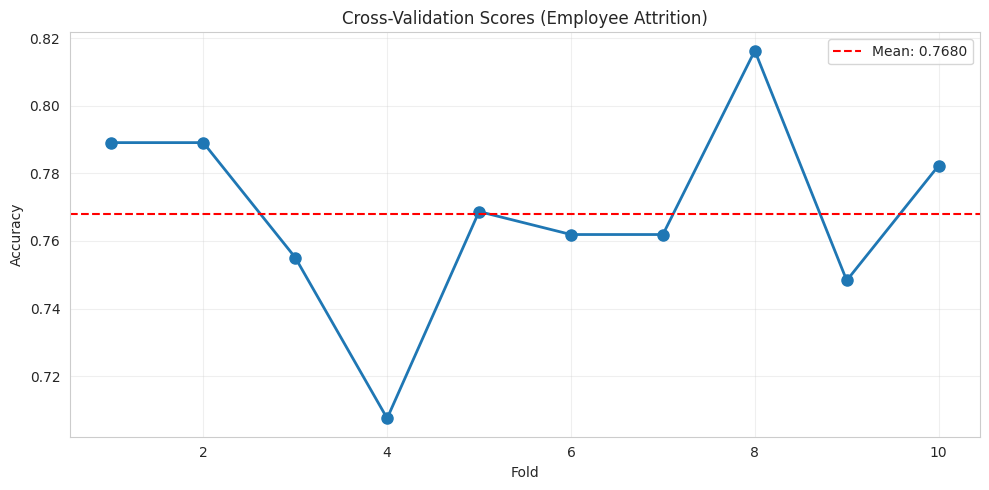

In [22]:
# 10-fold cross-validation on the full dataset (X, y before SMOTE split)
X_full = df.drop('Attrition', axis=1)
y_full = df['Attrition']

cv_scores = cross_val_score(dt_tuned, X_full, y_full, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation Results:")
print(f"  Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Min:           {cv_scores.min():.4f}")
print(f"  Max:           {cv_scores.max():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), cv_scores, marker='o', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--',
            label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores (Employee Attrition)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Model Comparison


MODEL COMPARISON:
                 Model  Accuracy  Precision  Recall  F1-Score
0        Decision Tree    0.8145     0.4324  0.4444    0.4384
1        Random Forest    0.8462     0.5625  0.2500    0.3462
2  Logistic Regression    0.7647     0.3788  0.6944    0.4902


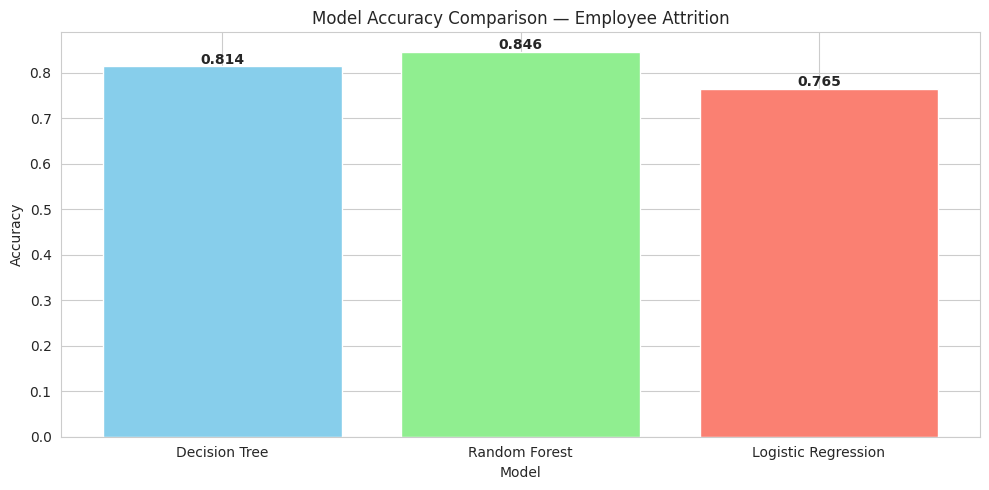

In [26]:
models = {
    'Decision Tree':      dt_tuned,
    'Random Forest':      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_m = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, y_pred_m),
        precision_score(y_test, y_pred_m),
        recall_score(y_test, y_pred_m),
        f1_score(y_test, y_pred_m)
    ])

comparison_df = pd.DataFrame(results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\nMODEL COMPARISON:")
print(comparison_df.round(4))

# Bar chart
plt.figure(figsize=(10, 5))
x_pos = range(len(comparison_df))
bars = plt.bar(x_pos, comparison_df['Accuracy'],
               color=['skyblue', 'lightgreen', 'salmon'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison — Employee Attrition')
plt.xticks(x_pos, comparison_df['Model'])
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Discussion and Conclusion

### Key Findings
- **OverTime** and **MonthlyIncome** consistently rank among the most important features for predicting employee attrition.
- The Decision Tree provides interpretable, rule-based explanations — valuable for HR policy decisions.
- SMOTE effectively addressed the class imbalance (≈ 16 % attrition), improving recall for the minority class.
- Feature engineering (e.g., `IncomePerYearAtCompany`, `TenureRatio`) contributed to model performance.

### Limitations
- The dataset is relatively small (1,470 records), which may limit generalization.
- Decision Trees are prone to overfitting; depth constraints and pruning were applied to mitigate this.
- Label encoding treats categorical variables as ordinal, which may introduce unintended ordinal relationships.

### How to Improve Accuracy
- Collect larger, more diverse HR datasets.
- Use ensemble methods such as Random Forest or Gradient Boosting.
- Apply SHAP values for more nuanced feature interpretation.
- Explore advanced imputation and encoding strategies.

### Conclusion
The Decision Tree classifier achieves a solid balance between **predictive performance** and **interpretability** for employee attrition prediction. Its ability to surface clear decision rules makes it particularly suitable for HR analytics, where explainability supports actionable workforce strategies.

### References
1. IBM HR Analytics Employee Attrition & Performance Dataset
2. Scikit-learn Decision Tree Documentation — https://scikit-learn.org
3. Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox. *JMLR*, 18(17), 1–5.
